<a href="https://colab.research.google.com/github/amit-sahu-a11y/ML_projects_for_practice/blob/main/model_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Linear Regression from Scratch

First, we'll import `numpy` for numerical operations and define a `LinearRegression` class. This class will include methods for initializing weights and bias, making predictions, and training the model using gradient descent.

In [5]:
import numpy as np

class LinearRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000, lambda_param=0.01):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.lambda_param = lambda_param # L2 regularization parameter
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent
        for _ in range(self.n_iterations):
            y_predicted = np.dot(X, self.weights) + self.bias

            # Calculate gradients
            dw = (1/n_samples) * np.dot(X.T, (y_predicted - y)) + self.lambda_param * self.weights # Add L2 regularization term
            db = (1/n_samples) * np.sum(y_predicted - y)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


### Generate Sample Data

To test our model, let's create some synthetic data with a linear relationship and add some noise.

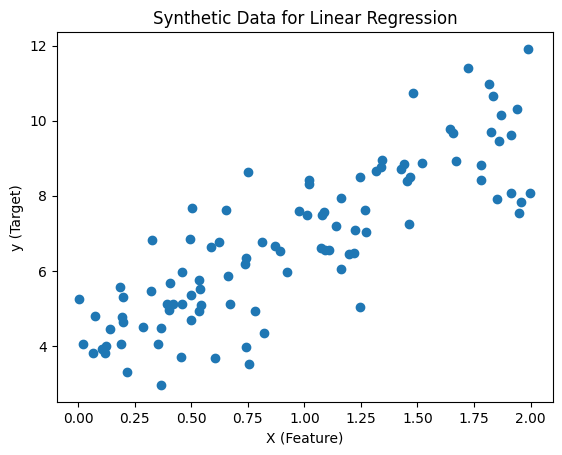

In [2]:
import matplotlib.pyplot as plt

# Generate synthetic data
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Plot the generated data
plt.scatter(X, y)
plt.xlabel('X (Feature)')
plt.ylabel('y (Target)')
plt.title('Synthetic Data for Linear Regression')
plt.show()

### Train and Evaluate the Model

Now, we'll instantiate our `LinearRegression` model, train it on the synthetic data, and then visualize its predictions against the actual data.

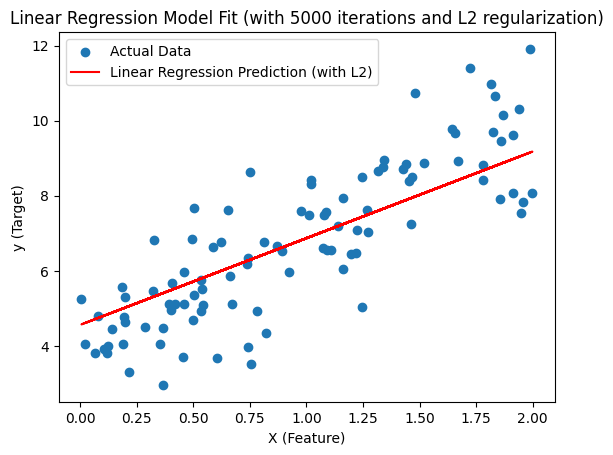

Learned weights: [2.30864257]
Learned bias: 4.560260744535049


In [6]:
# Instantiate and train the model with L2 regularization
model = LinearRegression(learning_rate=0.01, n_iterations=5000, lambda_param=0.1)
model.fit(X, y.flatten()) # Flatten y to match the model's expectation

# Make predictions
y_pred = model.predict(X)

# Plot the results
plt.scatter(X, y, label='Actual Data')
plt.plot(X, y_pred, color='red', label='Linear Regression Prediction (with L2)')
plt.xlabel('X (Feature)')
plt.ylabel('y (Target)')
plt.title('Linear Regression Model Fit (with 5000 iterations and L2 regularization)')
plt.legend()
plt.show()

print(f"Learned weights: {model.weights}")
print(f"Learned bias: {model.bias}")


In [7]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 1.3996432000682717


### Cross-Validation for Optimal `lambda_param`

To find the best `lambda_param` for L2 regularization, we'll use K-Fold cross-validation. This technique helps us evaluate the model's performance on different subsets of the data, providing a more robust estimate of how it will generalize to unseen data.

In [8]:
from sklearn.model_selection import KFold

# Define a range of lambda_param values to test
lambda_params = np.logspace(-4, 0, 20) # 20 values from 0.0001 to 1.0

# Number of folds for cross-validation
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Store MSE for each lambda_param
mse_scores = []

for lmbd in lambda_params:
    fold_mse = []
    for train_index, val_index in kf.split(X):
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]

        # Instantiate and train model with current lambda_param
        model_cv = LinearRegression(learning_rate=0.01, n_iterations=5000, lambda_param=lmbd)
        model_cv.fit(X_train, y_train.flatten())

        # Make predictions on validation set
        y_pred_cv = model_cv.predict(X_val)

        # Calculate MSE and store it
        mse = mean_squared_error(y_val, y_pred_cv)
        fold_mse.append(mse)

    # Store the average MSE for the current lambda_param
    mse_scores.append(np.mean(fold_mse))

# Find the optimal lambda_param
optimal_lambda_idx = np.argmin(mse_scores)
optimal_lambda = lambda_params[optimal_lambda_idx]

print(f"Optimal lambda_param: {optimal_lambda}")
print(f"Minimum average MSE: {mse_scores[optimal_lambda_idx]}")

Optimal lambda_param: 0.007847599703514606
Minimum average MSE: 1.2971874883408592


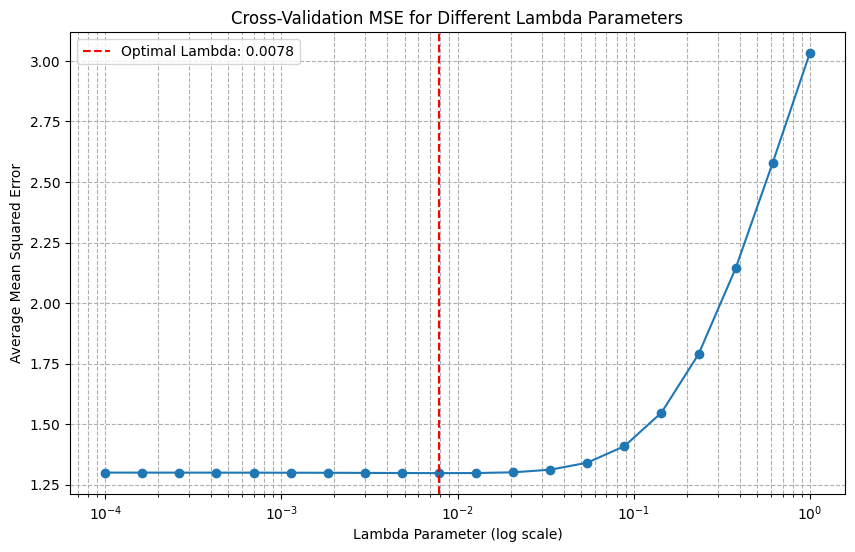

In [9]:
# Plot the MSE scores for different lambda_params
plt.figure(figsize=(10, 6))
plt.plot(lambda_params, mse_scores, marker='o')
plt.xscale('log')
plt.xlabel('Lambda Parameter (log scale)')
plt.ylabel('Average Mean Squared Error')
plt.title('Cross-Validation MSE for Different Lambda Parameters')
plt.grid(True, which="both", ls="--")
plt.axvline(x=optimal_lambda, color='r', linestyle='--', label=f'Optimal Lambda: {optimal_lambda:.4f}')
plt.legend()
plt.show()